In [2]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

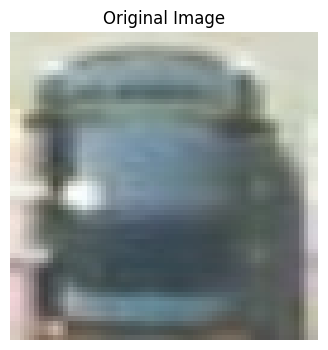

Image path: C:\Users\faisa\Desktop\ARTI404_Parking_Project\dataset\train\occupied\train_occupied_04763.jpg
Image shape: (64, 64, 3)


In [3]:
project_path = Path.cwd().parent
dataset_path = project_path / "dataset"

empty_folder = dataset_path / "train" / "empty"
occupied_folder = dataset_path / "train" / "occupied"

empty_images = list(empty_folder.glob("*.jpg"))
occupied_images = list(occupied_folder.glob("*.jpg"))

sample_path = random.choice(occupied_images)

img_bgr = cv2.imread(str(sample_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

print("Image path:", sample_path)
print("Image shape:", img_rgb.shape)

In [4]:
# Resize
resized = cv2.resize(img_rgb, (64, 64))

# Grayscale
gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

# Histogram Equalization
equalized = cv2.equalizeHist(gray)

# Gaussian Blur
blurred = cv2.GaussianBlur(equalized, (5, 5), 0)

# Edge Detection
edges = cv2.Canny(blurred, 50, 150)

# Normalization
normalized = resized / 255.0

print("Original shape:", img_rgb.shape)
print("Resized shape:", resized.shape)
print("Gray shape:", gray.shape)
print("Normalized min:", normalized.min())
print("Normalized max:", normalized.max())

Original shape: (64, 64, 3)
Resized shape: (64, 64, 3)
Gray shape: (64, 64)
Normalized min: 0.20784313725490197
Normalized max: 1.0


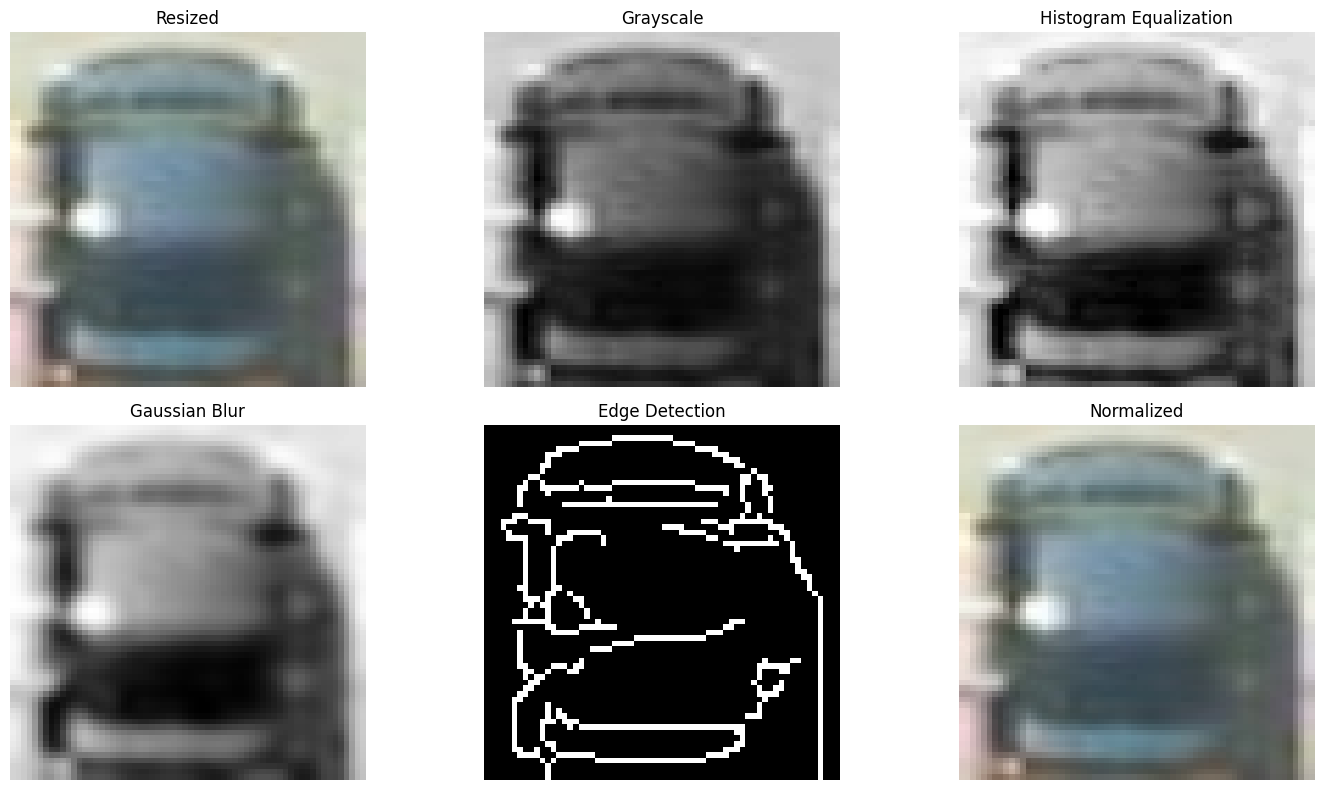

In [5]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(resized)
plt.title("Resized")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(edges, cmap="gray")
plt.title("Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(normalized)
plt.title("Normalized")
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
def preprocess_image(image_path, image_size=(64, 64)):
    img_bgr = cv2.imread(str(image_path))
    
    if img_bgr is None:
        return None
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, image_size)
    normalized = resized / 255.0
    
    return normalized